# MiniTaller — Entrenar tu primer modelo propio

Vamos a entrenar nuestro propio modelo usando un dataset de promedios de estudiantes de la Unisimón.
El dataset es sintético (generado) y lo usaremos para:

- **Modelo A — Regresión:** predecir la nota de un estudiante (un número entre 1.0 y 5.0)
- **Modelo B — Clasificación:** predecir si un estudiante aprueba o reprueba (nota ≥ 3.0)

Usaremos el paquete **scikit-learn**, el más popular para Machine Learning en Python.

## 1. Instalaciones Requeridas

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


## 2. Obtención del Dataset

En lugar de subir un archivo manualmente a Colab (que se borra cada vez que se cierra), lo cargamos directamente desde una URL pública en internet.

El dataset está alojado en GitHub y lo leemos con `pandas` usando `read_csv(url)`.

In [2]:
import pandas as pd

URL = "https://stivenson.github.io/datasets/promedios_estudiantes_unisimon.csv"

df = pd.read_csv(URL)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Dataset cargado correctamente.
Filas: 1000 | Columnas: 6


,codigo,nombre,carrera,semestre,materia,nota
0,CS20230001,Iván Sánchez Martínez,Comunicación Social,5,Producción Audiovisual,4.22
1,OD20220002,Mauricio Núñez Rodríguez,Odontología,7,Anatomía Dental,3.84
2,EN20220003,Camila Díaz Reyes,Enfermería,10,Urgencias,4.21
3,MD20240004,Fernando Vega Reyes,Medicina,10,Anatomía,4.32
4,PS20240005,Liliana Flores Guzmán,Psicología,6,Neuropsicología,4.20


## 3. Exploración Básica

Antes de entrenar cualquier modelo, siempre exploramos los datos para entender qué tenemos.

In [3]:
# Tipos de datos de cada columna
df.dtypes

codigo          str
nombre          str
carrera         str
semestre      int64
materia         str
nota        float64
dtype: object

In [4]:
# Estadísticas básicas de las columnas numéricas
df.describe()

,semestre,nota
count,1000.000000,1000.000000
mean,5.497000,3.743280
std,2.821339,0.583885
min,1.000000,1.880000
25%,3.000000,3.340000
50%,5.000000,3.730000
75%,8.000000,4.160000
max,10.000000,5.000000


In [5]:
# ¿Cuántos estudiantes hay por carrera?
df['carrera'].value_counts()

carrera
Arquitectura                          79
Administración de Empresas            78
Medicina                              77
Comunicación Social                   75
Negocios Internacionales              72
Enfermería                            69
Ingeniería Civil                      67
Derecho                               67
Ingeniería Industrial                 67
Odontología                           64
Licenciatura en Educación Infantil    61
Trabajo Social                        60
Ingeniería de Sistemas                57
Contaduría Pública                    55
Psicología                            52
Name: count, dtype: int64

## 4. Limpieza de Datos

Dos pasos básicos que siempre hacemos antes de entrenar un modelo:
- Eliminar **filas duplicadas** (misma información repetida)
- Eliminar **valores nulos** (celdas vacías)

In [6]:
antes = len(df)
df = df.drop_duplicates()
despues = len(df)
print(f"Filas eliminadas por duplicados: {antes - despues}")

Filas eliminadas por duplicados: 0


In [7]:
print("Valores nulos por columna:")
print(df.isnull().sum())

df = df.dropna()
print(f"\nFilas finales después de limpieza: {len(df)}")

Valores nulos por columna:
codigo      0
nombre      0
carrera     0
semestre    0
materia     0
nota        0
dtype: int64

Filas finales después de limpieza: 1000


## 5. Preparación de Variables

Los modelos de scikit-learn solo entienden números. Las columnas de texto (`carrera`, `materia`) hay que convertirlas a números usando **LabelEncoder**.

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_modelo = df.copy()

le_carrera = LabelEncoder()
le_materia = LabelEncoder()

df_modelo['carrera_cod'] = le_carrera.fit_transform(df_modelo['carrera'])
df_modelo['materia_cod'] = le_materia.fit_transform(df_modelo['materia'])

# Features (variables de entrada) y target (lo que queremos predecir)
FEATURES = ['carrera_cod', 'semestre', 'materia_cod']

X = df_modelo[FEATURES]
y_regresion    = df_modelo['nota']
y_clasificacion = (df_modelo['nota'] >= 3.0).astype(int)  # 1 = aprueba, 0 = reprueba

# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_regresion, y_clasificacion, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas")

Entrenamiento: 800 filas | Prueba: 200 filas


## 6. Modelo A — Regresión Lineal

**Objetivo:** predecir la nota (un número continuo entre 1.0 y 5.0).

**Métrica — MAE (Mean Absolute Error):**
> "En promedio, mi predicción se equivoca en X puntos."
> Si MAE = 0.5, el modelo se equivoca medio punto en promedio. ¡Fácil de interpretar!

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

modelo_reg = LinearRegression()
modelo_reg.fit(X_train, yr_train)

predicciones_reg = modelo_reg.predict(X_test)
mae = mean_absolute_error(yr_test, predicciones_reg)

print(f"MAE (Error Absoluto Medio): {mae:.2f} puntos")
print(f"Eso significa que el modelo se equivoca en promedio {mae:.2f} puntos en la nota.")

MAE (Error Absoluto Medio): 0.48 puntos
Eso significa que el modelo se equivoca en promedio 0.48 puntos en la nota.


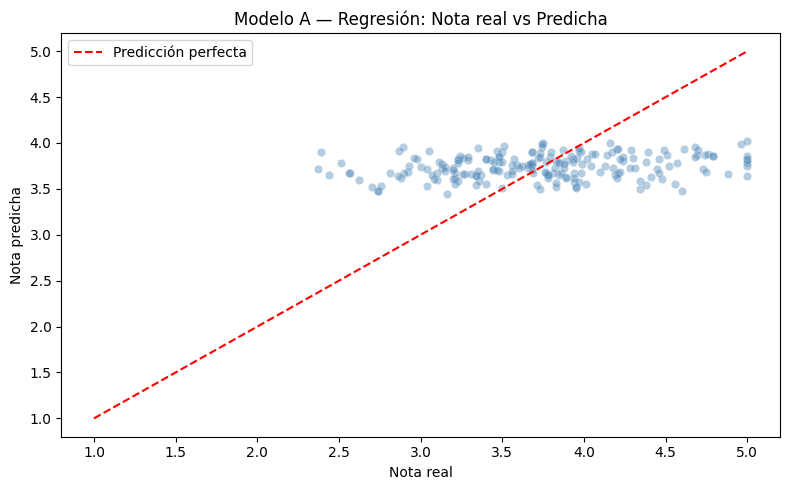

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(yr_test, predicciones_reg, alpha=0.4, color='steelblue', edgecolors='white', linewidths=0.3)
plt.plot([1, 5], [1, 5], 'r--', label='Predicción perfecta')
plt.xlabel('Nota real')
plt.ylabel('Nota predicha')
plt.title('Modelo A — Regresión: Nota real vs Predicha')
plt.legend()
plt.tight_layout()
plt.show()

# Mientras más cerca estén los puntos a la línea roja, mejor es el modelo.

## 7. Modelo B — Clasificación (¿Aprueba o Reprueba?)

**Objetivo:** predecir si un estudiante aprueba (nota ≥ 3.0) o reprueba (nota < 3.0).

Usamos un **Árbol de Decisión** — funciona como un diagrama de preguntas: "¿Es semestre > 5? ¿Es carrera X?"

**Métrica — Accuracy:**
> "De cada 100 predicciones, ¿cuántas acerté?"
> Accuracy = 0.90 → acerté el 90% de los casos.

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_clf.fit(X_train, yc_train)

predicciones_clf = modelo_clf.predict(X_test)
accuracy = accuracy_score(yc_test, predicciones_clf)

print(f"Accuracy: {accuracy:.2%}")
print(f"El modelo acertó el {accuracy:.2%} de las predicciones.")

Accuracy: 87.50%
El modelo acertó el 87.50% de las predicciones.


### Matriz de Confusión

La matriz de confusión nos muestra en detalle dónde acertó y dónde se equivocó el modelo:

|  | Predijo: Reprueba | Predijo: Aprueba |
|---|---|---|
| **Real: Reprueba** | ✅ Acierto | ❌ Error |
| **Real: Aprueba** | ❌ Error | ✅ Acierto |

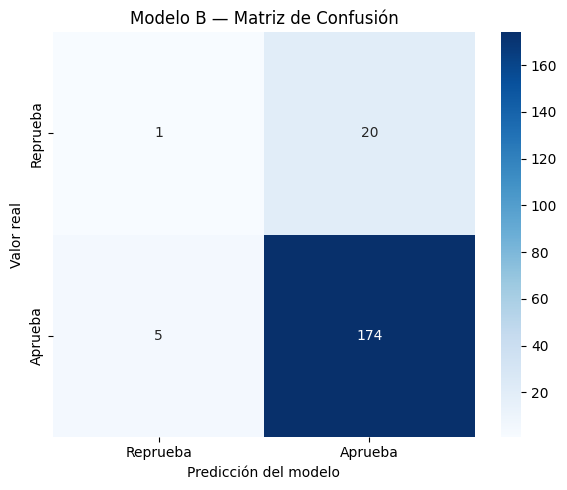

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yc_test, predicciones_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Reprueba', 'Aprueba'],
    yticklabels=['Reprueba', 'Aprueba']
)
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Modelo B — Matriz de Confusión')
plt.tight_layout()
plt.show()

## 8. Importancia de Variables

El árbol de decisión nos dice qué tan importante fue cada variable para tomar sus decisiones.

> La variable con la barra más larga es la que más influyó en la predicción.

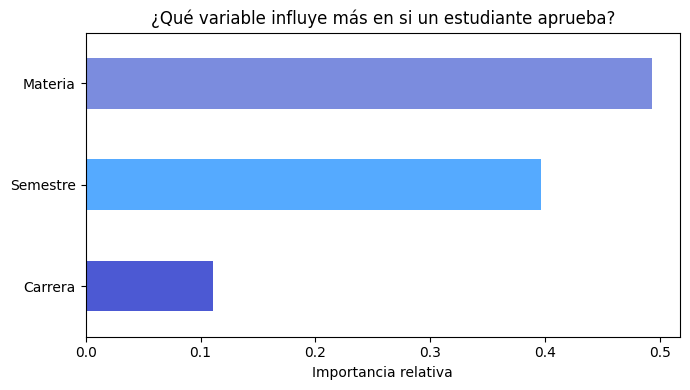

La variable más relevante para predecir si un estudiante aprueba es: Materia


In [13]:
importancias = pd.Series(
    modelo_clf.feature_importances_,
    index=['Carrera', 'Semestre', 'Materia']
).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importancias.plot(kind='barh', color=['#4C59D3', '#55AAFF', '#7B8CDE'])
plt.xlabel('Importancia relativa')
plt.title('¿Qué variable influye más en si un estudiante aprueba?')
plt.tight_layout()
plt.show()

mejor = importancias.idxmax()
print(f"La variable más relevante para predecir si un estudiante aprueba es: {mejor}")

## Resumen Final

| Modelo | Tipo | Qué predice | Métrica |
|---|---|---|---|
| Regresión Lineal | Regresión | Nota (1.0 – 5.0) | MAE |
| Árbol de Decisión | Clasificación | Aprueba / Reprueba | Accuracy |

**Conceptos aprendidos:**
- Cargar datos desde una URL remota con `pandas`
- Limpieza básica: duplicados y nulos
- Codificar variables de texto con `LabelEncoder`
- Dividir datos en entrenamiento y prueba (`train_test_split`)
- Entrenar y evaluar dos tipos de modelos con `scikit-learn`
- Visualizar resultados con `matplotlib` y `seaborn`

---
## Hallazgos y Análisis Crítico

Esta sección explica por qué los modelos se comportan como lo hacen — algo que las métricas solas no cuentan.

### Hallazgo 1 — ¿Por qué el Modelo A predice tan mal las notas bajas?

El gráfico de *Nota real vs Nota predicha* muestra que para notas reales entre **1.0 y 2.5**, el modelo predice valores alrededor de **3.5 – 3.8**. Se equivoca hasta 2 puntos. ¿Por qué?

**Razón 1 — El dataset está sesgado hacia notas altas.**
La mayoría de los estudiantes tiene notas entre 3.0 y 4.5. Los reprobados son minoría (~7%). La regresión lineal busca minimizar el error promedio, así que "aprende" a predecir cerca del promedio general (~3.8) porque eso le da el menor error en la mayoría de los casos.

**Razón 2 — Las variables disponibles son insuficientes.**
Tenemos solo 3 variables: `carrera`, `semestre` y `materia`. Estas explican una parte de la nota, pero la nota real depende de muchos factores no capturados: dedicación del estudiante, dificultad del profesor, si trabajó mientras estudiaba, etc.

**Razón 3 — La regresión lineal es un modelo simple.**
Asume que la relación entre las variables y la nota es una línea recta. En la realidad, esa relación es mucho más compleja y no lineal.

> 💡 **Lección clave:** Un modelo solo puede aprender lo que está en los datos. Si los datos no contienen la información necesaria para predecir algo, ningún algoritmo puede inventarla.

In [14]:
import numpy as np

# Distribución de notas en el dataset
total      = len(df)
reprobados = (df['nota'] < 3.0).sum()
aprobados  = (df['nota'] >= 3.0).sum()

print("=== Distribución de notas en el dataset ===")
print(f"Total estudiantes : {total}")
print(f"Aprobados  (≥ 3.0): {aprobados} ({aprobados/total:.1%})")
print(f"Reprobados (< 3.0): {reprobados} ({reprobados/total:.1%})")
print(f"\nPromedio general de notas: {df['nota'].mean():.2f}")

# Error del modelo por rango de nota real
print("\nError del modelo (MAE) por rango de nota real:")
yr_arr   = np.array(yr_test)
pred_arr = np.array(predicciones_reg)
for lo, hi in [(1.0, 2.0), (2.0, 3.0), (3.0, 4.0), (4.0, 5.01)]:
    mask = (yr_arr >= lo) & (yr_arr < hi)
    if mask.sum() == 0:
        continue
    error = np.abs(yr_arr[mask] - pred_arr[mask]).mean()
    print(f"  Nota real [{lo:.1f} – {hi:.1f}): MAE = {error:.2f}  (n={mask.sum()})")

=== Distribución de notas en el dataset ===
Total estudiantes : 1000
Aprobados  (≥ 3.0): 897 (89.7%)
Reprobados (< 3.0): 103 (10.3%)

Promedio general de notas: 3.74

Error del modelo (MAE) por rango de nota real:
  Nota real [2.0 – 3.0): MAE = 0.96  (n=21)
  Nota real [3.0 – 4.0): MAE = 0.29  (n=119)
  Nota real [4.0 – 5.0): MAE = 0.69  (n=60)


### Hallazgo 2 — ¿Por qué el Accuracy del 87% es engañoso?

El Modelo B reportó un accuracy de **~87.5%**. Suena muy bien, ¿verdad? Pero veamos qué hay detrás.

**El problema: dataset desbalanceado.**
Si el 87% de los estudiantes aprueba, un modelo que prediga **"aprueba" para absolutamente todos** — sin ver ni un solo dato — obtendría también ~87% de accuracy. Eso se llama el **"clasificador tonto"**.

**¿Cómo detectarlo?** Comparando nuestro modelo contra ese clasificador tonto. Si los números son similares, nuestro modelo no está aprendiendo nada útil.

**¿Qué métrica usar en su lugar?**
- **Precision:** de los que predije que reprueban, ¿cuántos realmente reprobaron?
- **Recall:** de todos los que reprobaron, ¿cuántos detecté correctamente?
- **F1-Score:** balance entre ambos — el más honesto cuando los datos están desbalanceados.

> 💡 **Lección clave:** El accuracy miente cuando una clase es mucho más frecuente que la otra. Siempre revisa la matriz de confusión y el F1-Score.

In [15]:
from sklearn.dummy import DummyClassifier

# Clasificador tonto: siempre predice la clase más frecuente
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, yc_train)
dummy_pred = dummy.predict(X_test)
dummy_acc  = accuracy_score(yc_test, dummy_pred)

print("=== Comparación de Accuracy ===")
print(f"Clasificador tonto (siempre dice 'aprueba'): {dummy_acc:.2%}")
print(f"Nuestro Árbol de Decisión                 : {accuracy_score(yc_test, predicciones_clf):.2%}")
print()
print("=== Distribución real de clases en el set de prueba ===")
conteo = yc_test.value_counts(normalize=True)
print(f"Aprueba  (1): {conteo.get(1, 0):.1%}")
print(f"Reprueba (0): {conteo.get(0, 0):.1%}")

=== Comparación de Accuracy ===
Clasificador tonto (siempre dice 'aprueba'): 89.50%
Nuestro Árbol de Decisión                 : 87.50%

=== Distribución real de clases en el set de prueba ===
Aprueba  (1): 89.5%
Reprueba (0): 10.5%


In [16]:
from sklearn.metrics import classification_report

print("=== Reporte completo del Árbol de Decisión ===")
print(classification_report(yc_test, predicciones_clf, target_names=['Reprueba', 'Aprueba']))
print("Precision : de los que predije que reprueban, ¿cuántos realmente reprobaron?")
print("Recall    : de todos los que reprobaron, ¿cuántos detecté correctamente?")
print("F1-Score  : balance entre Precision y Recall (el más honesto en datos desbalanceados)")

=== Reporte completo del Árbol de Decisión ===
              precision    recall  f1-score   support

    Reprueba       0.17      0.05      0.07        21
     Aprueba       0.90      0.97      0.93       179

    accuracy                           0.88       200
   macro avg       0.53      0.51      0.50       200
weighted avg       0.82      0.88      0.84       200

Precision : de los que predije que reprueban, ¿cuántos realmente reprobaron?
Recall    : de todos los que reprobaron, ¿cuántos detecté correctamente?
F1-Score  : balance entre Precision y Recall (el más honesto en datos desbalanceados)
